**The paper:** 
>Volatility of Mutator Phenotypes at Single
Cell Resolution

**The data object:**
>Novel mutation count per cell division for all lineages

**The random variable chosen:**

>Mutation count

**What the paper does:**
>Models mutation rate in mutator phenotypes of yeast. It counts the number of mutations in each cell division and fits it to a 2-Poisson model.

**The generative model proposed:**

**Parameters and assumptions:**

**The forward simulation:**

**The parameterization/fitting:**

**What/if the model adds to the paper:**

**Model limitations/how it breaks:**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
df = pd.read_excel("data/mutation_counts.xlsx", header=0, skiprows=[1], index_col=0)
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.astype(float)

lineages = [list(df[column].dropna()) for column in df.columns]

print(df)
print(lineages)

           B    C    D     E   F*   G1   G2    H
Lineage                                         
3        0.0  3.0  2.0   2.0  3.0  1.0  NaN  7.0
4        2.0  7.0  2.0   3.0  7.0  1.0  NaN  0.0
5        0.0  6.0  0.0   1.0  1.0  0.0  7.0  2.0
6        3.0  0.0  3.0   6.0  3.0  0.0  6.0  0.0
7        2.0  0.0  0.0   0.0  2.0  3.0  0.0  4.0
8        4.0  2.0  0.0   0.0  NaN  6.0  5.0  3.0
9        1.0  3.0  1.0   0.0  NaN  4.0  0.0  4.0
10       3.0  4.0  1.0   8.0  0.0  5.0  NaN  1.0
11       4.0  4.0  4.0   0.0  5.0  3.0  NaN  4.0
12       NaN  6.0  5.0  10.0  2.0  5.0  NaN  1.0
13       NaN  5.0  3.0   NaN  3.0  4.0  NaN  1.0
14       NaN  1.0  0.0   NaN  1.0  NaN  NaN  3.0
15       NaN  0.0  9.0   NaN  NaN  NaN  NaN  NaN
16       NaN  NaN  4.0   NaN  NaN  NaN  NaN  NaN
17       NaN  NaN  2.0   NaN  NaN  NaN  NaN  NaN
[[0.0, 2.0, 0.0, 3.0, 2.0, 4.0, 1.0, 3.0, 4.0], [3.0, 7.0, 6.0, 0.0, 0.0, 2.0, 3.0, 4.0, 4.0, 6.0, 5.0, 1.0, 0.0], [2.0, 2.0, 0.0, 3.0, 0.0, 0.0, 1.0, 1.0, 4.0, 5.0, 3

233.0 85 10.0 [20, 12, 10, 14, 11, 6, 5, 4, 1, 1, 1]
2.7411764705882353


<BarContainer object of 11 artists>

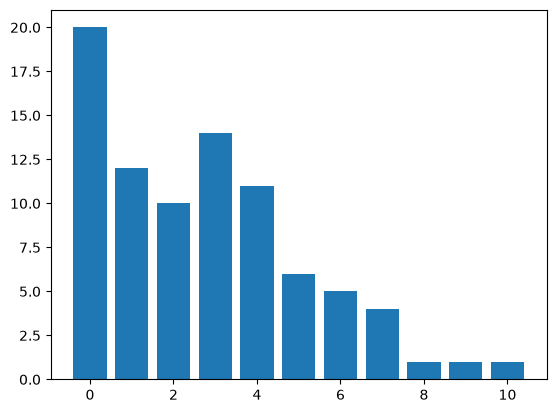

In [76]:
total = 0
N = 0 # Number of cell divisions
max_mutation_count = max([max(x) for x in lineages])
mutation_counts = [0] * (int(max_mutation_count) + 1)

for lineage in lineages:
    for mutation_count in lineage:
        count = int(mutation_count)
        total += mutation_count
        N += 1
        mutation_counts[count] += 1


print(total, N, max_mutation_count, mutation_counts)
print(total/N)

plt.bar(range(int(max_mutation_count)+1), mutation_counts)